In [2]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tools.particle_swarm_optimization as pso
import seaborn as sns

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [3]:
folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

## Inicialización
#pso.generate_first_population(folder_path, 10)


In [4]:
# Run simulation

# trial, subject = 0, 0
# for trial in range(10):
#     for subject in range(10):

#         if len(pso.get_result(folder_path, trial, subject)) == 0:
#             os.system("python -m src.run_model_busse "+str(trial)+" "+str(subject))

#         if len(pso.get_result(folder_path, trial, subject)) == 0:
#             pso.save_imposed_result(folder_path, trial, subject, [0, 0, 0, 0])
    
#     if trial < 10:
#         pso.generate_next_iteration(folder_path, trial)



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Aug 13 16:24:47 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.
RNG seed: 44
Total number of virtual processes: 1
---------> Creating the model...
---> Creating Microcircuits...
---> Creating networks V1_A...
Data will be written to: /home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20240813162447
  Directory has been created.

Neuron numbers are scaled by a factor of 0.100.
Indegrees are scaled by a factor of 0.100.
  Weights and DC input are adjusted to compensate.

Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
  Creating thalamic multimeters.
Cre

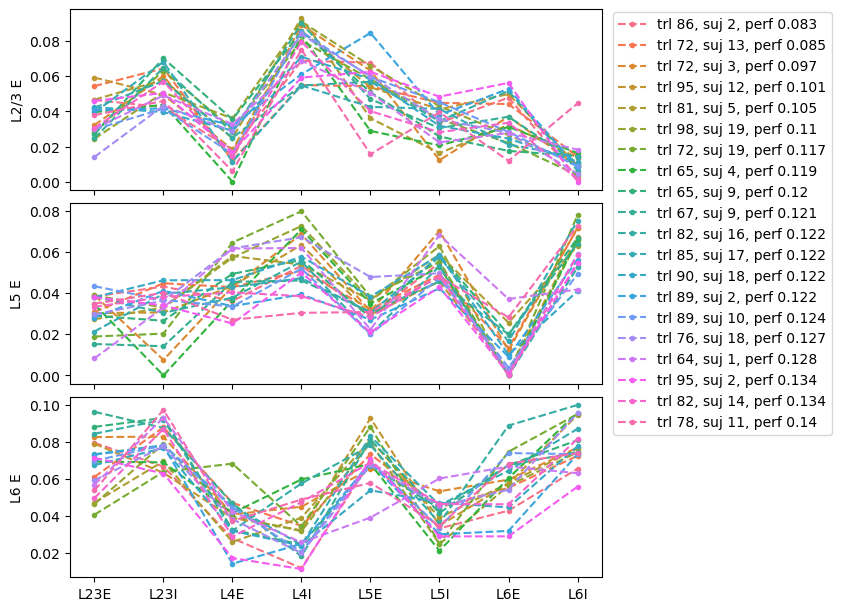

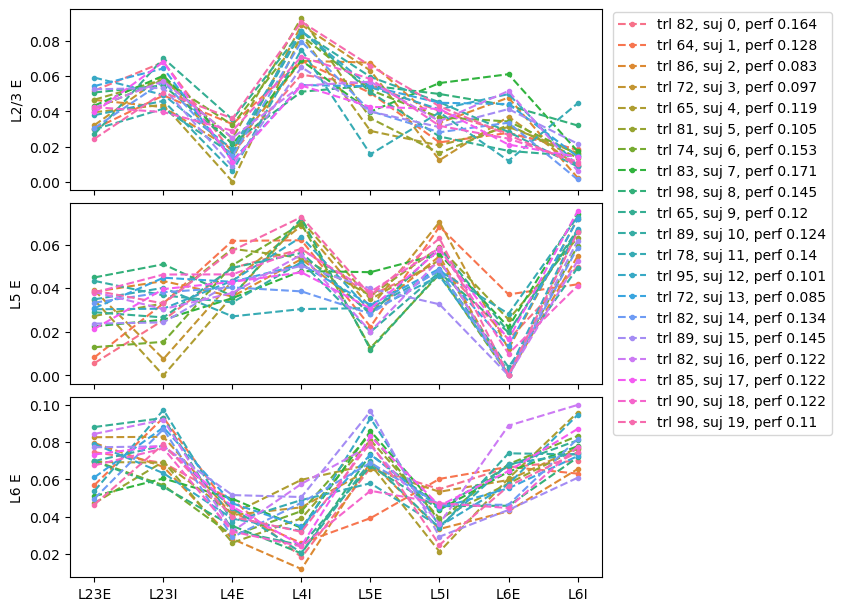

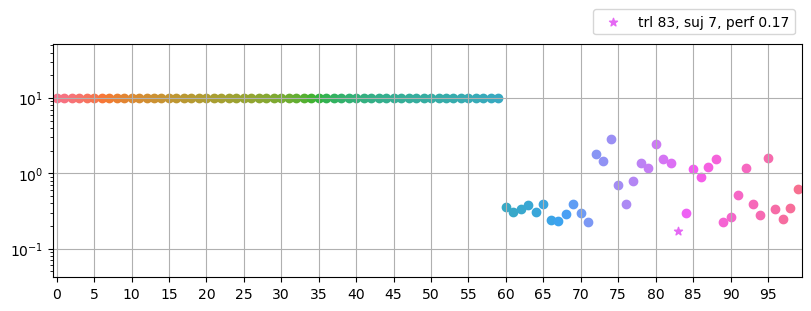

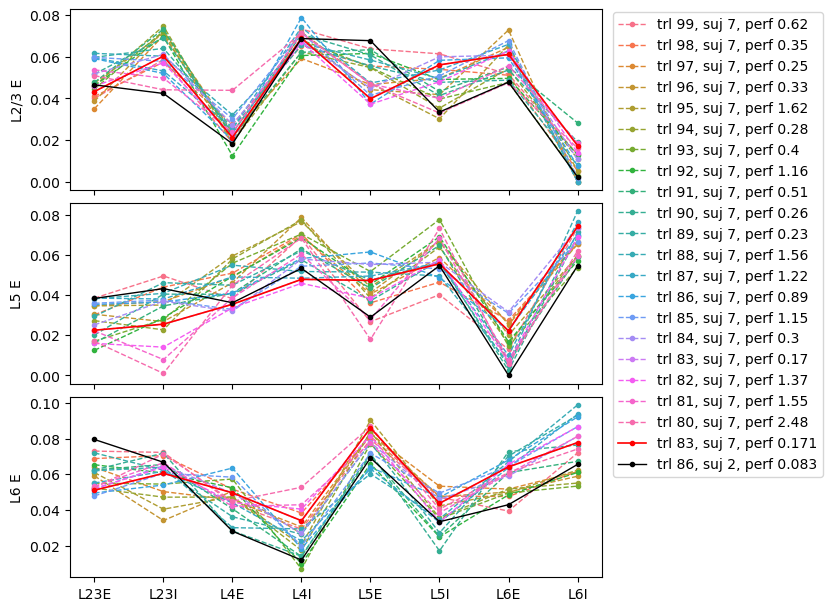

In [7]:
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')

suj = 7
pso.plot_best_params(folder_path, 'all')
pso.plot_best_params(folder_path, 'sub')

#pso.plot_params(folder_path, 59,-1)
#pso.plot_performance(folder_path, -1, -1, -1)

pso.plot_performance(folder_path, -1, suj, -1)
pso.plot_params(folder_path, -1, suj)

#pso.plot_activity(folder_path, -1, -1, -10)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

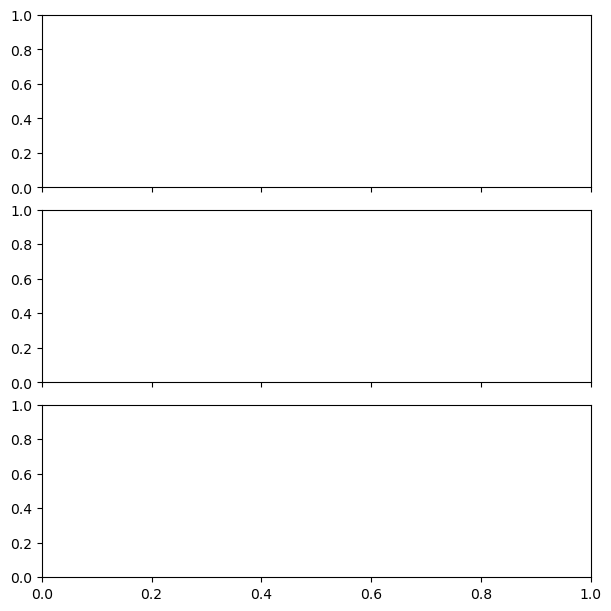

In [78]:
folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

pso.plot_best_params_32(folder_path, 'all')
pso.plot_best_params_32(folder_path, 'sub')

[25.          2.          0.58810732  0.78559343  0.7440174   0.68358714
  0.06941504]


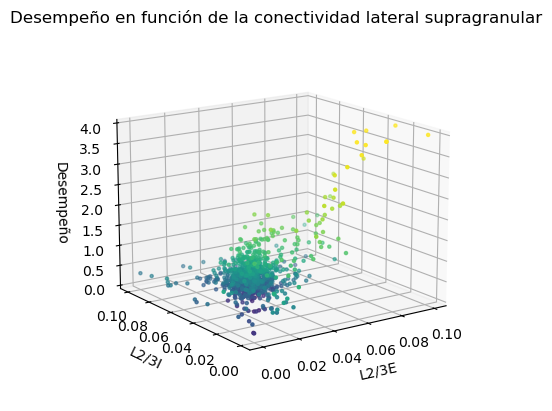

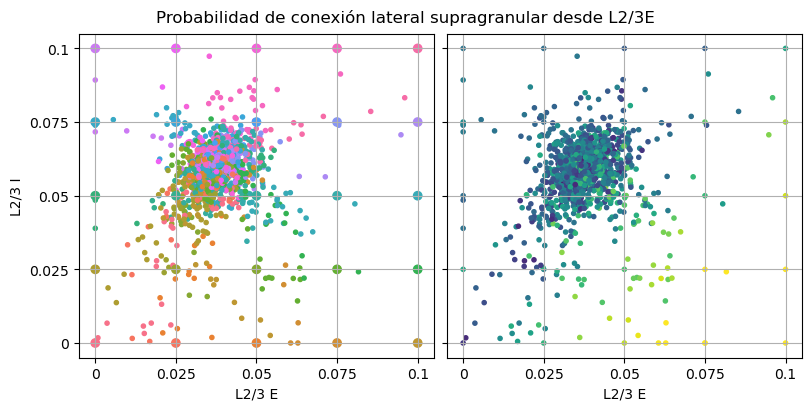

Coeficiente beta1:  [1.40673771]
Error cuadrático medio: 0.00
Estadístico R_2: 0.88


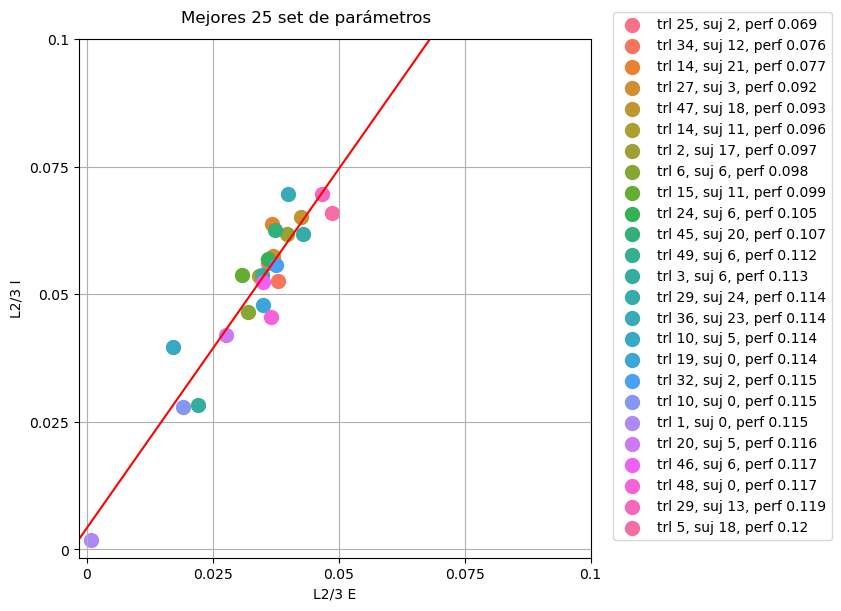

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

folder_path = os.path.join(os.getcwd(), 'results/wagatsuma/')

# add columns names
cols = np.array(['trials', 'subjects'])
params = range(8*3)
names = np.concatenate((cols, params), axis=None)
df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)

cols = np.array(['trials', 'subjects'])
params = range(5)
names = np.concatenate((cols, params), axis=None)
df2 = pd.read_csv(os.path.join(folder_path, 'results.csv'), header=None, names=names)
best = df2.sort_values('4').values
print(best[0])
X = df['0'].values
Y = df['1'].values
Z = df2['4'].values
Z[Z>4]=4



fig = plt.figure(layout='constrained', figsize=(8,4))
ax = fig.add_subplot(projection='3d') #
ax.scatter(X, Y, Z, marker='.', c=np.log(Z))
ax.set_zlim(0,4)
# Set the azimuth and elevation angles
ax.view_init(azim=235, elev=15)
ax.set_xlabel('L2/3E')
ax.set_ylabel('L2/3I')
ax.set_zlabel('Desempeño')
fig.suptitle('Desempeño en función de la conectividad lateral supragranular')



clrs = sns.color_palette('husl', n_colors=25)
fig, ax = plt.subplots(1,2, layout='constrained', figsize=(8,4), sharey=True)
ax[0].scatter(X, Y,  marker='.', c=clrs*50)
ax[0].scatter(X[:25], Y[:25],  marker='o', c=clrs)
ax[0].set_ylabel('L2/3 I')
ax[0].set_xlabel('L2/3 E')
lin = [0,0.025,0.05,0.075,0.1]
ax[0].set_xticks(lin, lin)
ax[0].set_yticks(lin, lin)

ax[1].scatter(X, Y,  marker='.', c=np.log(Z))
ax[1].set_xlabel('L2/3 E')
ax[1].set_xticks(lin, lin)

ax[0].grid(visible=True)
ax[1].grid(visible=True)
fig.suptitle('Probabilidad de conexión lateral supragranular desde L2/3E')
plt.show()







ee, ei = [], []
fig, ax = plt.subplots(1, layout='constrained', figsize=(6,6), sharey=True)
for i, suj in enumerate(best):
    suj_suj = df[(df['trials']==suj[0]) & (df['subjects']==suj[1])].values[0]
    ee.append(suj_suj[2])
    ei.append(suj_suj[3])
    ax.scatter(suj_suj[2], suj_suj[3], marker='o', s=100, c=clrs[i],
        label='trl '+str(int(suj[0]))+
            ', suj '+str(int(suj[1]))+
            ', perf '+str(round(suj[6],3)))
    if i == 24:
        break

# Create linear regression object
regr = LinearRegression()

ee = np.array(ee)
ei = np.array(ei)
regr.fit(ee.reshape(25,1), ei.reshape(25,1))
eiy = regr.predict(np.array([[-0.1],[0.1]]))


ax.set_ylabel('L2/3 I')
ax.set_xlabel('L2/3 E')
lin = [0,0.025,0.05,0.075,0.1]
ax.set_xticks(lin, lin)
ax.set_yticks(lin, lin)

bottom, top = plt.ylim()  # return the current ylim
a1, a2 = plt.xlim()  # return the current ylim
ax.plot([[-0.1],[0.1]],eiy,'r')

plt.ylim([bottom, top])
plt.xlim([a1, a2])
ax.grid(visible=True)
fig.legend(loc='upper left', bbox_to_anchor=(1.0,1),
            fancybox=True, shadow=False, ncol=1)
fig.suptitle('Mejores 25 set de parámetros')

# Ahora puedo obtener el coeficiente b_1
print(u'Coeficiente beta1: ', regr.coef_[0])
 
# Podemos predecir usando el modelo
y_pred = regr.predict(ee.reshape(25,1))
 
# Por último, calculamos el error cuadrático medio y el estadístico R^2
print(u'Error cuadrático medio: %.2f' % mean_squared_error(ei.reshape(25,1), y_pred))
print(u'Estadístico R_2: %.2f' % r2_score(ei.reshape(25,1), y_pred))
plt.show()

In [4]:
## intento de merge de las bases de datos

merge_result = False
if merge_result: 
    # Results
    cols = np.array(['trials', 'subjects'])
    params = range(5)
    names = np.concatenate((cols, params), axis=None)

    df0 = pd.read_csv(os.path.join(folder_path, 'results0.csv'), header=None, names=names)
    df1 = pd.read_csv(os.path.join(folder_path, 'results1.csv'), header=None, names=names)
    m = df0.columns.to_list()

    trial = df0['trials'].unique()
    subject = df0['subjects'].unique()

    for j, trl in enumerate(trial):
        for i, suj in enumerate(subject):

            activity = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)

        for i, suj in enumerate(subject):

            activity = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
            n_df = pd.DataFrame([np.concatenate(([trl, suj+10], activity), axis=None)])

            n_df.to_csv(os.path.join(folder_path, 'results.csv'), mode='a', index=False, header=False)


# Swarm
cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df0 = pd.read_csv(os.path.join(folder_path, 'swarm0.csv'), header=None, names=names)
df1 = pd.read_csv(os.path.join(folder_path, 'swarm1.csv'), header=None, names=names)
m = df0.columns.to_list()

trial = df0['trials'].unique()
subject = df0['subjects'].unique()

for j, trl in enumerate(trial):
    for i, suj in enumerate(subject):

        params = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)

    for i, suj in enumerate(subject):

        params = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj+10], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm.csv'), mode='a', index=False, header=False)


Variance explained by each principal component: [0.18641047 0.13898987 0.08367169 0.06064917 0.0497528  0.04474006
 0.04151911 0.03761107 0.03656184 0.03180902]
Variance explained by each principal component: 0.7117151023801312


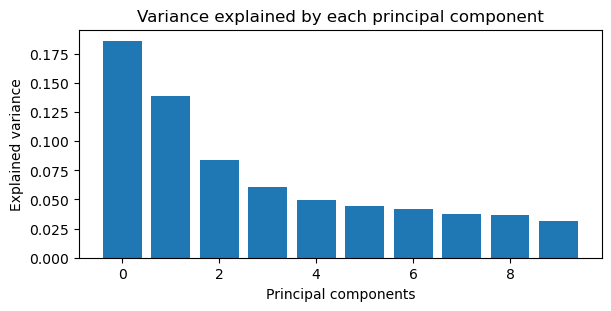

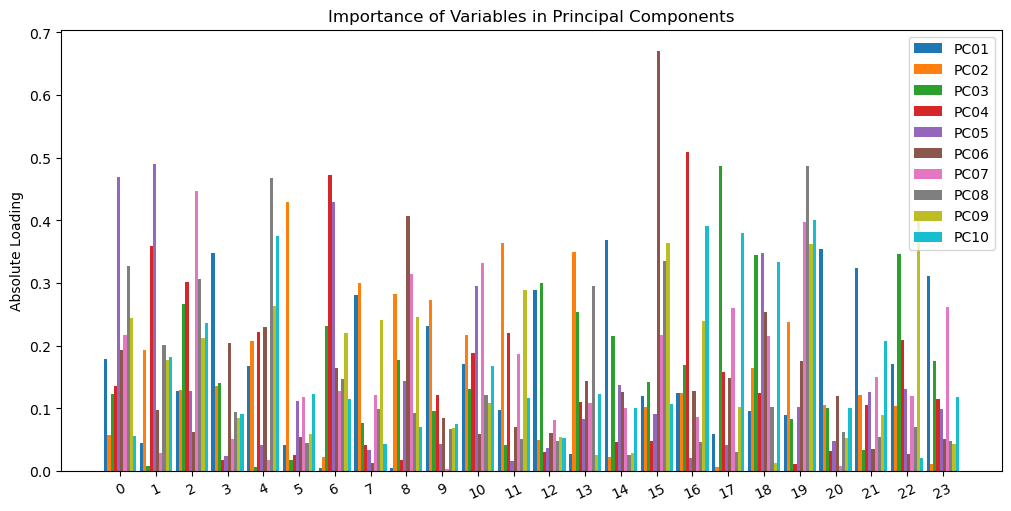

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

################################################################################
# PCA cluster
# Separate features and group information
cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df = pd.read_csv(os.path.join(folder_path, 'swarm.csv'), header=None, names=names)
pca_metrics = df.columns.to_list()
features = df[pca_metrics[2:]]
group_info = df[['trials', 'subjects']]

# Standardize the data (necessary for a good PCA)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Principal component analysis (PCA)
n_comp = 10
pca = PCA(n_components=n_comp)
principal_components = pca.fit_transform(scaled_features)

comp_names = ['PC01', 'PC02', 'PC03', 'PC04', 'PC05', 'PC06', 'PC07', 'PC08', 'PC09','PC10',
            'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19','PC20',
            'PC21', 'PC22', 'PC23', 'PC24']

# Visualize the variance explained by each principal component
explained_variance = pca.explained_variance_ratio_
print("Variance explained by each principal component:", explained_variance)
print("Variance explained by each principal component:", np.sum(explained_variance))

# Plot the variance explained by each principal component
fig, ax = plt.subplots(layout='constrained', figsize=(6, 3))
bars = plt.bar(range(len(explained_variance)), explained_variance, align='center')
#plt.xticks(range(len(explained_variance)), comp_names[:len(explained_variance)])
plt.xlabel('Principal components')
plt.ylabel('Explained variance')
plt.title('Variance explained by each principal component')
plt.show()

# A new DataFrame is generated with the PCA principal components
loadings = pca.components_.T
pca_df = pd.DataFrame(loadings, index=features.columns, columns=comp_names[:len(explained_variance)])

# Visualize the importance of the variables in the principal components
fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))
bar_l, x_pos = 0.9/n_comp, np.arange(0,len(pca_metrics[2:]))
for i in range(n_comp):
    plt.bar(x_pos-((bar_l/2)*(n_comp-1))+i*bar_l, np.abs(pca_df[comp_names[i]]), width=bar_l, label=comp_names[i])

plt.xticks(range(len(pca_metrics[2:])), pca_df.index, rotation=25)
plt.ylabel('Absolute Loading')
plt.title('Importance of Variables in Principal Components')
plt.legend()
plt.show()